# ¿Conviene ser Data Analyst, Data Scientist o Data Engineer en Argentina en 2026?
### Un análisis de la Encuesta de Sueldos IT de sysarmy (edición 2026.1)

**Autor:** Agustín Luca Jeon
**Fuente de datos:** [Encuesta de sueldos sysarmy 2026.1](https://sysar.my/sueldos20261) — 4.939 respuestas válidas, recolectadas en marzo de 2026.
**Licencia del dataset:** Creative Commons Atribución-NoComercial-CompartirIgual 4.0 Internacional.

**Objetivo:** salir de la pregunta genérica "¿cuánto gana un Data Analyst?" y responder algo más útil para quien está eligiendo *en qué especializarse dentro de datos*: ¿hay diferencias reales de sueldo, protección ante la inflación o brecha de género entre ser BI Analyst / Data Analyst, Data Scientist o Data Engineer en el mercado argentino? ¿El stack técnico (Python, SQL) realmente se traduce en mejor pago?

Esta no es una encuesta aleatoria de la población — es una muestra de auto-selección de gente que sigue a sysarmy en redes/Discord, mayormente desarrollo/infra. Esa limitación se retoma al final.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from scipy.stats import mannwhitneyu
from matplotlib.ticker import FuncFormatter

sns.set_theme(style="whitegrid", font_scale=1.05)
PALETTE = {"data": "#2E5EAA", "ref": "#B0B7C3", "highlight": "#E0673B"}
pd.set_option("display.float_format", lambda x: f"{x:,.0f}")

millones_fmt = FuncFormatter(lambda x, _: f"{x/1e6:.1f}")

## 1. Carga y limpieza

El archivo que publica sysarmy es el export directo del Google Sheet de respuestas: las primeras 9 filas son instrucciones de uso (licencia, cómo bajar el csv, link al GPT de consulta), no datos. Hay que saltearlas explícitamente — si no, pandas interpreta esas celdas como encabezado y arruina todos los tipos de columna.

In [2]:
df = pd.read_csv("sueldos_sysarmy_2026_1.csv", skiprows=9)
print(f"Filas: {df.shape[0]}  ·  Columnas: {df.shape[1]}")
df.head(3)


Filas: 4939  ·  Columnas: 60


,donde_estas_trabajando,dedicacion,tipo_de_contrato,ultimo_salario_mensual_o_retiro_bruto_en_pesos_argentinos,ultimo_salario_mensual_o_retiro_neto_en_pesos_argentinos,pagos_en_dolares,si_tu_sueldo_esta_dolarizado_cual_fue_el_ultimo_valor_del_dolar_que_tomaron,recibis_algun_tipo_de_bono,a_que_esta_atado_el_bono,tuviste_actualizaciones_de_tus_ingresos_laborales_durante_el_ultimo_semestre,...,cuanto_cobras_por_guardia,aclara_el_numero_que_ingresaste_en_el_campo_anterior,salir_o_seguir_contestando_sobre_estudios,tengo_edad,genero,habias_respondido_nuestra_encuesta_en_ediciones_anteriores,cuales_consideras_que_son_las_mejores_empresas_de_it_para_trabajar_en_este_momento_en_tu_ciudad,sueldo_dolarizado,seniority,_sal
0,Mendoza,Full-Time,Staff (planta permanente),"3,000,000","2,400,000",Mi sueldo está dolarizado (pero cobro en moned...,1300,No,Performance individual,No,...,NaN,NaN,NaN,45,Mujer Cis,Sí,NaN,True,Senior,"3,000,000"
1,Santa Fe,Full-Time,Contractor,"5,000,000","5,000,000",Cobro todo el salario en dólares,1400,No,No recibo bono,No,...,NaN,NaN,NaN,50,Mujer Cis,Sí,NaN,True,Senior,"5,000,000"
2,Buenos Aires,Full-Time,Tercerizado (trabajo a través de consultora o ...,"4,600,000","3,600,000",Cobro parte del salario en dólares,1436,No,No recibo bono,Uno,...,0,Porcentaje de mi sueldo bruto,Terminar encuesta,36,Mujer Cis,Sí,NaN,True,Senior,"4,600,000"


In [3]:
# La columna '_sal' es un duplicado exacto del sueldo bruto (probablemente una copia
# interna de sysarmy para sus propios gráficos). La eliminamos para no arrastrar redundancia.
assert (df["_sal"] == df["ultimo_salario_mensual_o_retiro_bruto_en_pesos_argentinos"]).all()
df = df.drop(columns=["_sal"])

sal_col = "ultimo_salario_mensual_o_retiro_bruto_en_pesos_argentinos"
print("Nulos en sueldo bruto:", df[sal_col].isna().sum())
print("Sueldos <= 0:", (df[sal_col] <= 0).sum())
df[sal_col].describe()


Nulos en sueldo bruto: 0
Sueldos <= 0: 0


count        4,939
mean     3,876,029
std      2,492,699
min        200,000
25%      2,166,336
50%      3,268,000
75%      4,944,960
max     20,000,000
Name: ultimo_salario_mensual_o_retiro_bruto_en_pesos_argentinos, dtype: float64

**Nota de limpieza:** el dataset que publica sysarmy ya viene relativamente depurado (no hay nulos ni sueldos en cero en la columna principal). El trabajo de limpieza acá es más de *comprensión de estructura* (filas de instrucciones, columna duplicada, columnas de texto libre y multi-selección) que de reparación de datos rotos — algo común en encuestas gestionadas por una comunidad técnica que ya filtra outliers obvios antes de publicar.

## 2. Panorama general del mercado IT (antes de enfocarnos en datos)

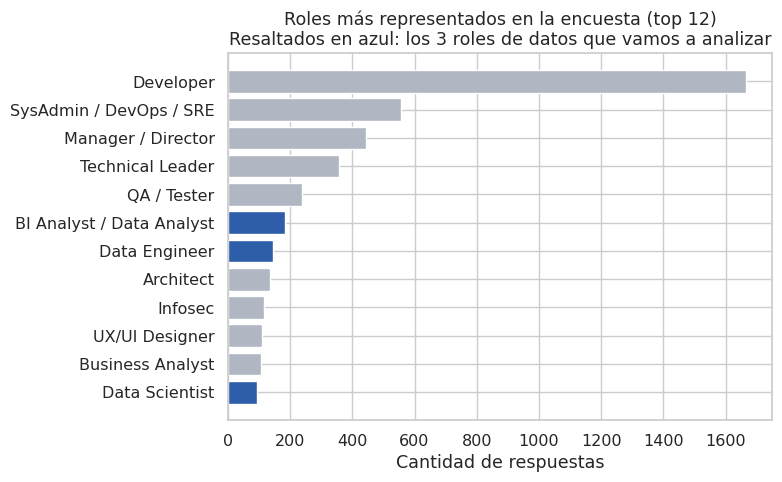

In [4]:
top_roles = df["trabajo_de"].value_counts().head(12)

fig, ax = plt.subplots(figsize=(8, 5))
colors = [PALETTE["data"] if r in ["BI Analyst / Data Analyst", "Data Scientist", "Data Engineer"]
          else PALETTE["ref"] for r in top_roles.index]
ax.barh(top_roles.index[::-1], top_roles.values[::-1], color=colors[::-1])
ax.set_xlabel("Cantidad de respuestas")
ax.set_title("Roles más representados en la encuesta (top 12)\nResaltados en azul: los 3 roles de datos que vamos a analizar")
plt.tight_layout()
plt.savefig("fig1_roles.png", dpi=130)
plt.show()


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=df, x="seniority", y=sal_col, order=["Junior", "Semi-Senior", "Senior"],
            color=PALETTE["ref"], ax=ax, showfliers=False)
ax.yaxis.set_major_formatter(millones_fmt)
ax.set_ylabel("Sueldo bruto mensual (millones de ARS)")
ax.set_xlabel("")
ax.set_title("Distribución de sueldos por seniority — todo el mercado IT\n(la asimetría justifica usar mediana, no promedio, en todo el análisis)")
plt.tight_layout()
plt.savefig("fig2_boxplot_general.png", dpi=130)
plt.show()

La distribución de sueldos tiene cola larga a la derecha (algunos sueldos muy altos, sobre todo en roles de management o contractors dolarizados). Por eso, en todo lo que sigue, comparamos **medianas** y no promedios — el promedio se infla con esos pocos valores extremos y da una imagen poco representativa de "el sueldo típico".

## 3. Foco: roles de datos

Filtramos a los tres roles de datos: **BI Analyst / Data Analyst**, **Data Scientist** y **Data Engineer**. Quedan 420 respuestas — suficientes para comparar medianas y tendencias, aunque hay que ser prudente con los cortes más finos (ej. por género dentro de un solo rol).

In [6]:
data_roles = ["BI Analyst / Data Analyst", "Data Scientist", "Data Engineer"]
sub = df[df["trabajo_de"].isin(data_roles)].copy()
print(f"N roles de datos: {len(sub)}")
sub["trabajo_de"].value_counts()


N roles de datos: 420


trabajo_de
BI Analyst / Data Analyst    183
Data Engineer                144
Data Scientist                93
Name: count, dtype: int64

## 4. Insight 1 — ¿Cuánto cobra cada rol de datos, y cómo se compara con Developer?

Tomamos Developer como referencia porque es, por lejos, el rol más numeroso del mercado (1.666 respuestas) — el "piso de comparación" implícito que casi todo el mundo usa.

In [7]:
roles_plot = ["BI Analyst / Data Analyst", "Data Scientist", "Data Engineer", "Developer"]
tabla1 = (df[df["trabajo_de"].isin(roles_plot)]
          .groupby(["trabajo_de", "seniority"])[sal_col]
          .agg(mediana="median", n="count")
          .round(0))
tabla1


mediana    n
trabajo_de                seniority                 
BI Analyst / Data Analyst Junior      1,785,000   43
                          Semi-Senior 2,557,772   76
                          Senior      3,308,028   64
Data Engineer             Junior      1,900,000   22
                          Semi-Senior 3,087,933   60
                          Senior      4,285,858   62
Data Scientist            Junior      2,154,704   15
                          Semi-Senior 4,317,450   40
                          Senior      4,800,000   38
Developer                 Junior      1,566,000  199
                          Semi-Senior 2,705,000  635
                          Senior      4,028,000  832

In [ ]:
pivot = (df[df["trabajo_de"].isin(roles_plot)]
         .pivot_table(index="seniority", columns="trabajo_de", values=sal_col, aggfunc="median")
         .reindex(["Junior", "Semi-Senior", "Senior"])[roles_plot])

fig, ax = plt.subplots(figsize=(9, 5.5))
pivot.plot(kind="bar", ax=ax,
           color=[PALETTE["data"], PALETTE["highlight"], "#5FA8D3", PALETTE["ref"]])
ax.yaxis.set_major_formatter(millones_fmt)
ax.set_ylabel("Sueldo bruto mensual mediano (millones de ARS)")
ax.set_xlabel("")
ax.set_title("Sueldo mediano por rol y seniority")
ax.legend(title="", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("fig3_sueldo_rol_seniority.png", dpi=130)
plt.show()

**Lectura:**
- Como punto de entrada, **Data Analyst Junior ($1.785.000) ya está por encima de Developer Junior ($1.566.000) y QA Junior**. No es un mal lugar para arrancar.
- El problema es el techo: en **Senior, Data Analyst ($3.31M) queda *por debajo* de Developer ($4.03M)** y de los otros dos caminos de datos.
- **Data Scientist es, sueldo a sueldo, el rol mejor pago de los tres en todas las seniorities** — y ya en Semi-Senior ($4.32M) supera a un Developer Senior ($4.03M).
- **Data Engineer** queda en el medio, pero con una progresión muy fuerte hacia Senior ($4.29M, casi igual a Data Scientist).

Para alguien que arranca en Data Analyst (como yo), esto sugiere algo concreto: el rol de entrada está bien pago, pero **el crecimiento de sueldo a mediano plazo está en moverse hacia Data Engineer o Data Scientist**, no en quedarse indefinidamente en Analyst puro.

## 5. Insight 2 — ¿Quién está mejor protegido de la inflación?

`sueldo_dolarizado` indica si la persona cobra todo o parte de su sueldo en dólares (o tiene el sueldo "dolarizado" aunque cobre en pesos). En un contexto de inflación en pesos, cobrar en dólares es una protección real del poder de compra — vale la pena ver si los tres roles de datos están igual de expuestos.

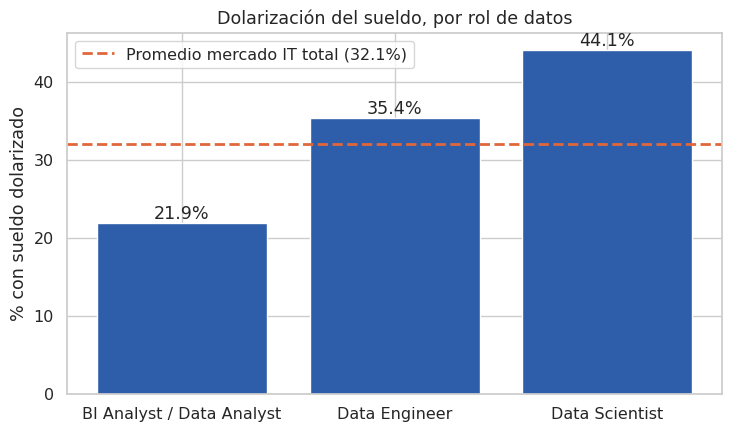

In [9]:
dolar_por_rol = (df[df["trabajo_de"].isin(data_roles)]
                 .groupby("trabajo_de")["sueldo_dolarizado"]
                 .mean().mul(100).round(1)
                 .reindex(["BI Analyst / Data Analyst", "Data Engineer", "Data Scientist"]))
mercado_total = df["sueldo_dolarizado"].mean() * 100

fig, ax = plt.subplots(figsize=(7.5, 4.5))
bars = ax.bar(dolar_por_rol.index, dolar_por_rol.values, color=PALETTE["data"])
ax.axhline(mercado_total, color=PALETTE["highlight"], linestyle="--", linewidth=2,
           label=f"Promedio mercado IT total ({mercado_total:.1f}%)")
ax.set_ylabel("% con sueldo dolarizado")
ax.set_title("Dolarización del sueldo, por rol de datos")
ax.legend()
for b in bars:
    ax.annotate(f"{b.get_height():.1f}%", (b.get_x() + b.get_width()/2, b.get_height()),
                ha="center", va="bottom")
plt.tight_layout()
plt.savefig("fig4_dolarizacion.png", dpi=130)
plt.show()


**Lectura:** acá aparece la misma asimetría que en el Insight 1. **Data Analyst es el rol menos dolarizado de los tres (21.9%), bastante por debajo del promedio del mercado IT (32.1%)**. Data Scientist, en cambio, está *por encima* del promedio (44.1%) — son los perfiles que más fácilmente consiguen trabajo remoto para clientes del exterior o en empresas con pricing en USD. Data Engineer queda cerca del promedio general (35.4%).

Combinado con el Insight 1: el camino de Data Analyst no solo paga menos en seniority alta, sino que además está más expuesto a la devaluación del peso que los otros dos.

## 6. Insight 3 — Brecha de género dentro de roles de datos (con control estadístico)

Comparar la mediana de sueldo entre géneros sin más es un error común: si, por ejemplo, hay más mujeres en roles Junior, la diferencia "de género" en realidad sería una diferencia de seniority disfrazada. Para evitar ese sesgo, usamos una regresión lineal (`log(sueldo) ~ género + seniority + rol + años de experiencia`) que estima el efecto de género *controlando* por las otras variables.

Nos quedamos con "Hombre Cis" y "Mujer Cis" porque son las únicas categorías con tamaño de muestra razonable dentro de roles de datos; las demás (No binarie, Prefiero no decir, etc.) tienen muy pocos casos para un análisis cuantitativo serio.

In [10]:
sub_genero = sub[sub["genero"].isin(["Hombre Cis", "Mujer Cis"])].copy()
print(sub_genero["genero"].value_counts())

mediana_h = sub_genero.loc[sub_genero["genero"] == "Hombre Cis", sal_col].median()
mediana_m = sub_genero.loc[sub_genero["genero"] == "Mujer Cis", sal_col].median()
print(f"\nMediana Hombres Cis: ${mediana_h:,.0f}")
print(f"Mediana Mujeres Cis: ${mediana_m:,.0f}")
print(f"Brecha sin ajustar: {(mediana_h - mediana_m) / mediana_h * 100:.1f}%")


genero
Hombre Cis    298
Mujer Cis     111
Name: count, dtype: int64

Mediana Hombres Cis: $3,052,158
Mediana Mujeres Cis: $2,900,000
Brecha sin ajustar: 5.0%


In [11]:
sub_genero["es_mujer"] = (sub_genero["genero"] == "Mujer Cis").astype(int)
sub_genero["log_sueldo"] = np.log(sub_genero[sal_col])

modelo = smf.ols(
    "log_sueldo ~ es_mujer + anos_de_experiencia + C(seniority) + C(trabajo_de)",
    data=sub_genero
).fit()

modelo.summary2().tables[1][["Coef.", "Std.Err.", "P>|t|", "[0.025", "0.975]"]].round(4)


,Coef.,Std.Err.,P>|t|,[0.025,0.975]
Intercept,14,0,0,14,14
C(seniority)[T.Semi-Senior],0,0,0,0,1
C(seniority)[T.Senior],1,0,0,1,1
C(trabajo_de)[T.Data Engineer],0,0,0,0,0
C(trabajo_de)[T.Data Scientist],0,0,0,0,1
es_mujer,-0,0,1,-0,0
anos_de_experiencia,-0,0,1,-0,0


**Lectura — y por qué hay que leerla con cuidado:**

- **Sin ajustar por nada**, las mujeres en roles de datos ganan una mediana ~5% menor que los hombres.
- **Ajustando por seniority, rol específico y años de experiencia**, el coeficiente de género es **-3.4%, pero con p-valor = 0.54** — estadísticamente no distinguible de cero. El intervalo de confianza al 95% (-14.5%, +7.6%) incluye holgadamente el cero.

Esto **no significa que no exista brecha de género** en el mercado de datos argentino — significa que, *con esta muestra de 409 personas (298 hombres, 111 mujeres)*, no hay evidencia estadística suficiente para afirmarla una vez controlado por seniority y rol. Es un resultado honesto, no una negación: estudios con muestras más grandes (o que controlen por más variables, como tamaño de empresa o modalidad de contratación) podrían detectar un efecto que acá no alcanzamos a separar del ruido. Afirmar "hay brecha de X%" con este N sería sobre-interpretar los datos.

## 7. Insight 4 — ¿Usar Python y SQL realmente paga mejor dentro de roles de datos?

Esta es la pregunta más directamente relevante para mi propio plan de desarrollo: ¿el tiempo que invierta en reforzar Python y SQL se traduce en algo medible en el mercado, o es solo intuición?

In [12]:
col_tech = "lenguajes_de_programacion_o_tecnologias_que_utilices_en_tu_puesto_actual"
sub["usa_python"] = sub[col_tech].fillna("").str.contains("Python")
sub["usa_sql"] = sub[col_tech].fillna("").str.contains("SQL")

resultados = []
for var, etiqueta in [("usa_python", "Usa Python"), ("usa_sql", "Usa SQL")]:
    con = sub.loc[sub[var], sal_col]
    sin = sub.loc[~sub[var], sal_col]
    _, p = mannwhitneyu(con, sin, alternative="two-sided")
    resultados.append({
        "Variable": etiqueta,
        "Mediana CON": con.median(), "n CON": con.shape[0],
        "Mediana SIN": sin.median(), "n SIN": sin.shape[0],
        "Diferencia %": (con.median() - sin.median()) / sin.median() * 100,
        "p-valor (Mann-Whitney)": round(p, 4),
    })
pd.DataFrame(resultados)


,Variable,Mediana CON,n CON,Mediana SIN,n SIN,Diferencia %,p-valor (Mann-Whitney)
0,Usa Python,"3,100,000",346,"2,638,357",74,17,0
1,Usa SQL,"3,071,933",316,"2,650,000",104,16,0


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
for ax, var, titulo in zip(axes, ["usa_python", "usa_sql"], ["Python", "SQL"]):
    sns.boxplot(data=sub, x=var, y=sal_col, ax=ax, showfliers=False,
                palette=[PALETTE["ref"], PALETTE["data"]])
    ax.set_xticklabels(["No usa", f"Usa {titulo}"])
    ax.set_xlabel("")
    ax.set_title(f"Sueldo según uso de {titulo}\n(roles de datos)")
    ax.yaxis.set_major_formatter(millones_fmt)
    ax.set_ylabel("Sueldo bruto mensual (millones de ARS)" if var == "usa_python" else "")
plt.tight_layout()
plt.savefig("fig5_python_sql.png", dpi=130)
plt.show()

In [14]:
# Para descartar que el efecto sea solo "los seniors usan más Python":
# comparamos la mediana usando/no usando Python DENTRO de cada seniority.
sub.groupby(["seniority", "usa_python"])[sal_col].median().reindex(
    ["Junior", "Semi-Senior", "Senior"], level=0)


seniority    usa_python
Junior       False        1,826,000
             True         1,900,000
Semi-Senior  False        2,515,054
             True         3,052,158
Senior       False        3,507,028
             True         4,200,000
Name: ultimo_salario_mensual_o_retiro_bruto_en_pesos_argentinos, dtype: float64

**Lectura:**
- Quienes usan **Python** dentro de roles de datos ganan una mediana de **$3.100.000 vs. $2.638.357** de quienes no lo usan — diferencia de ~17%, estadísticamente significativa (p = 0.0027).
- Quienes usan **SQL** ganan **$3.071.933 vs. $2.650.000** — ~16%, también significativa (p = 0.047), aunque con menos margen.
- Y esto **no es solo un efecto de seniority**: dentro de cada nivel (Junior, Semi-Senior, Senior) por separado, quienes usan Python siguen ganando más que quienes no — la brecha es más marcada justamente en Senior ($4.2M vs $3.5M).

A diferencia del Insight 3, acá sí hay evidencia sólida: **dentro de roles de datos, el stack técnico (Python en particular) está asociado a mejor sueldo en todos los niveles de seniority**, no solo como proxy de experiencia.

## 8. Resumen ejecutivo

1. **Data Analyst es un buen punto de entrada, pero con techo bajo**: paga mejor que Developer/QA en Junior, pero en Senior queda por debajo de los otros dos caminos de datos y del propio Developer.
2. **Data Scientist es el camino con mejor sueldo y mejor protección ante la inflación** (44% dolarizado, vs. 22% en Data Analyst) en este corte de datos.
3. **La brecha de género dentro de roles de datos no es estadísticamente distinguible de cero una vez controlada por seniority y rol** — con el tamaño de muestra disponible (n=409). Esto no cierra el tema, pero evita una conclusión apresurada en una u otra dirección.
4. **Python y SQL se asocian con sueldos significativamente más altos dentro de roles de datos, en todas las seniorities** — la inversión en stack técnico no es solo intuición, tiene respaldo en los datos.

**Para mi propio caso:** el análisis sugiere que el camino lógico de mediano plazo no es quedarme en Data Analyst puro, sino capitalizar la base de Python que ya tengo (y reforzar SQL con evidencia real, no solo listada en el CV) para moverme hacia un perfil más Data Engineer / Data Scientist.


## 9. Limitaciones del dataset

- **No es una muestra aleatoria de todo el mercado IT argentino**: son personas que siguen a sysarmy en redes, Discord o Slack — probablemente sobrerrepresenta a quienes ya están conectados con la comunidad tech online, y puede subrepresentar a quienes recién entran al mercado o trabajan en empresas más tradicionales/no-tech.
- **Sueldos auto-reportados**, sin ningún tipo de verificación contra recibo de sueldo.
- La encuesta está orientada principalmente a roles de **desarrollo e infraestructura**; los roles de datos son una porción menor del total (420 de 4.939, ~8.5%), lo que limita cuánto se puede desagregar sin que las muestras se vuelvan chicas (como pasó con el corte por género).
- Es una **foto de marzo de 2026**, no una serie histórica — no permite ver tendencia, solo nivel.
